<a href="https://colab.research.google.com/github/omotowar80-cloud/-Healthcare-Operational-Analytics-Dashboard/blob/main/operational_risk_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

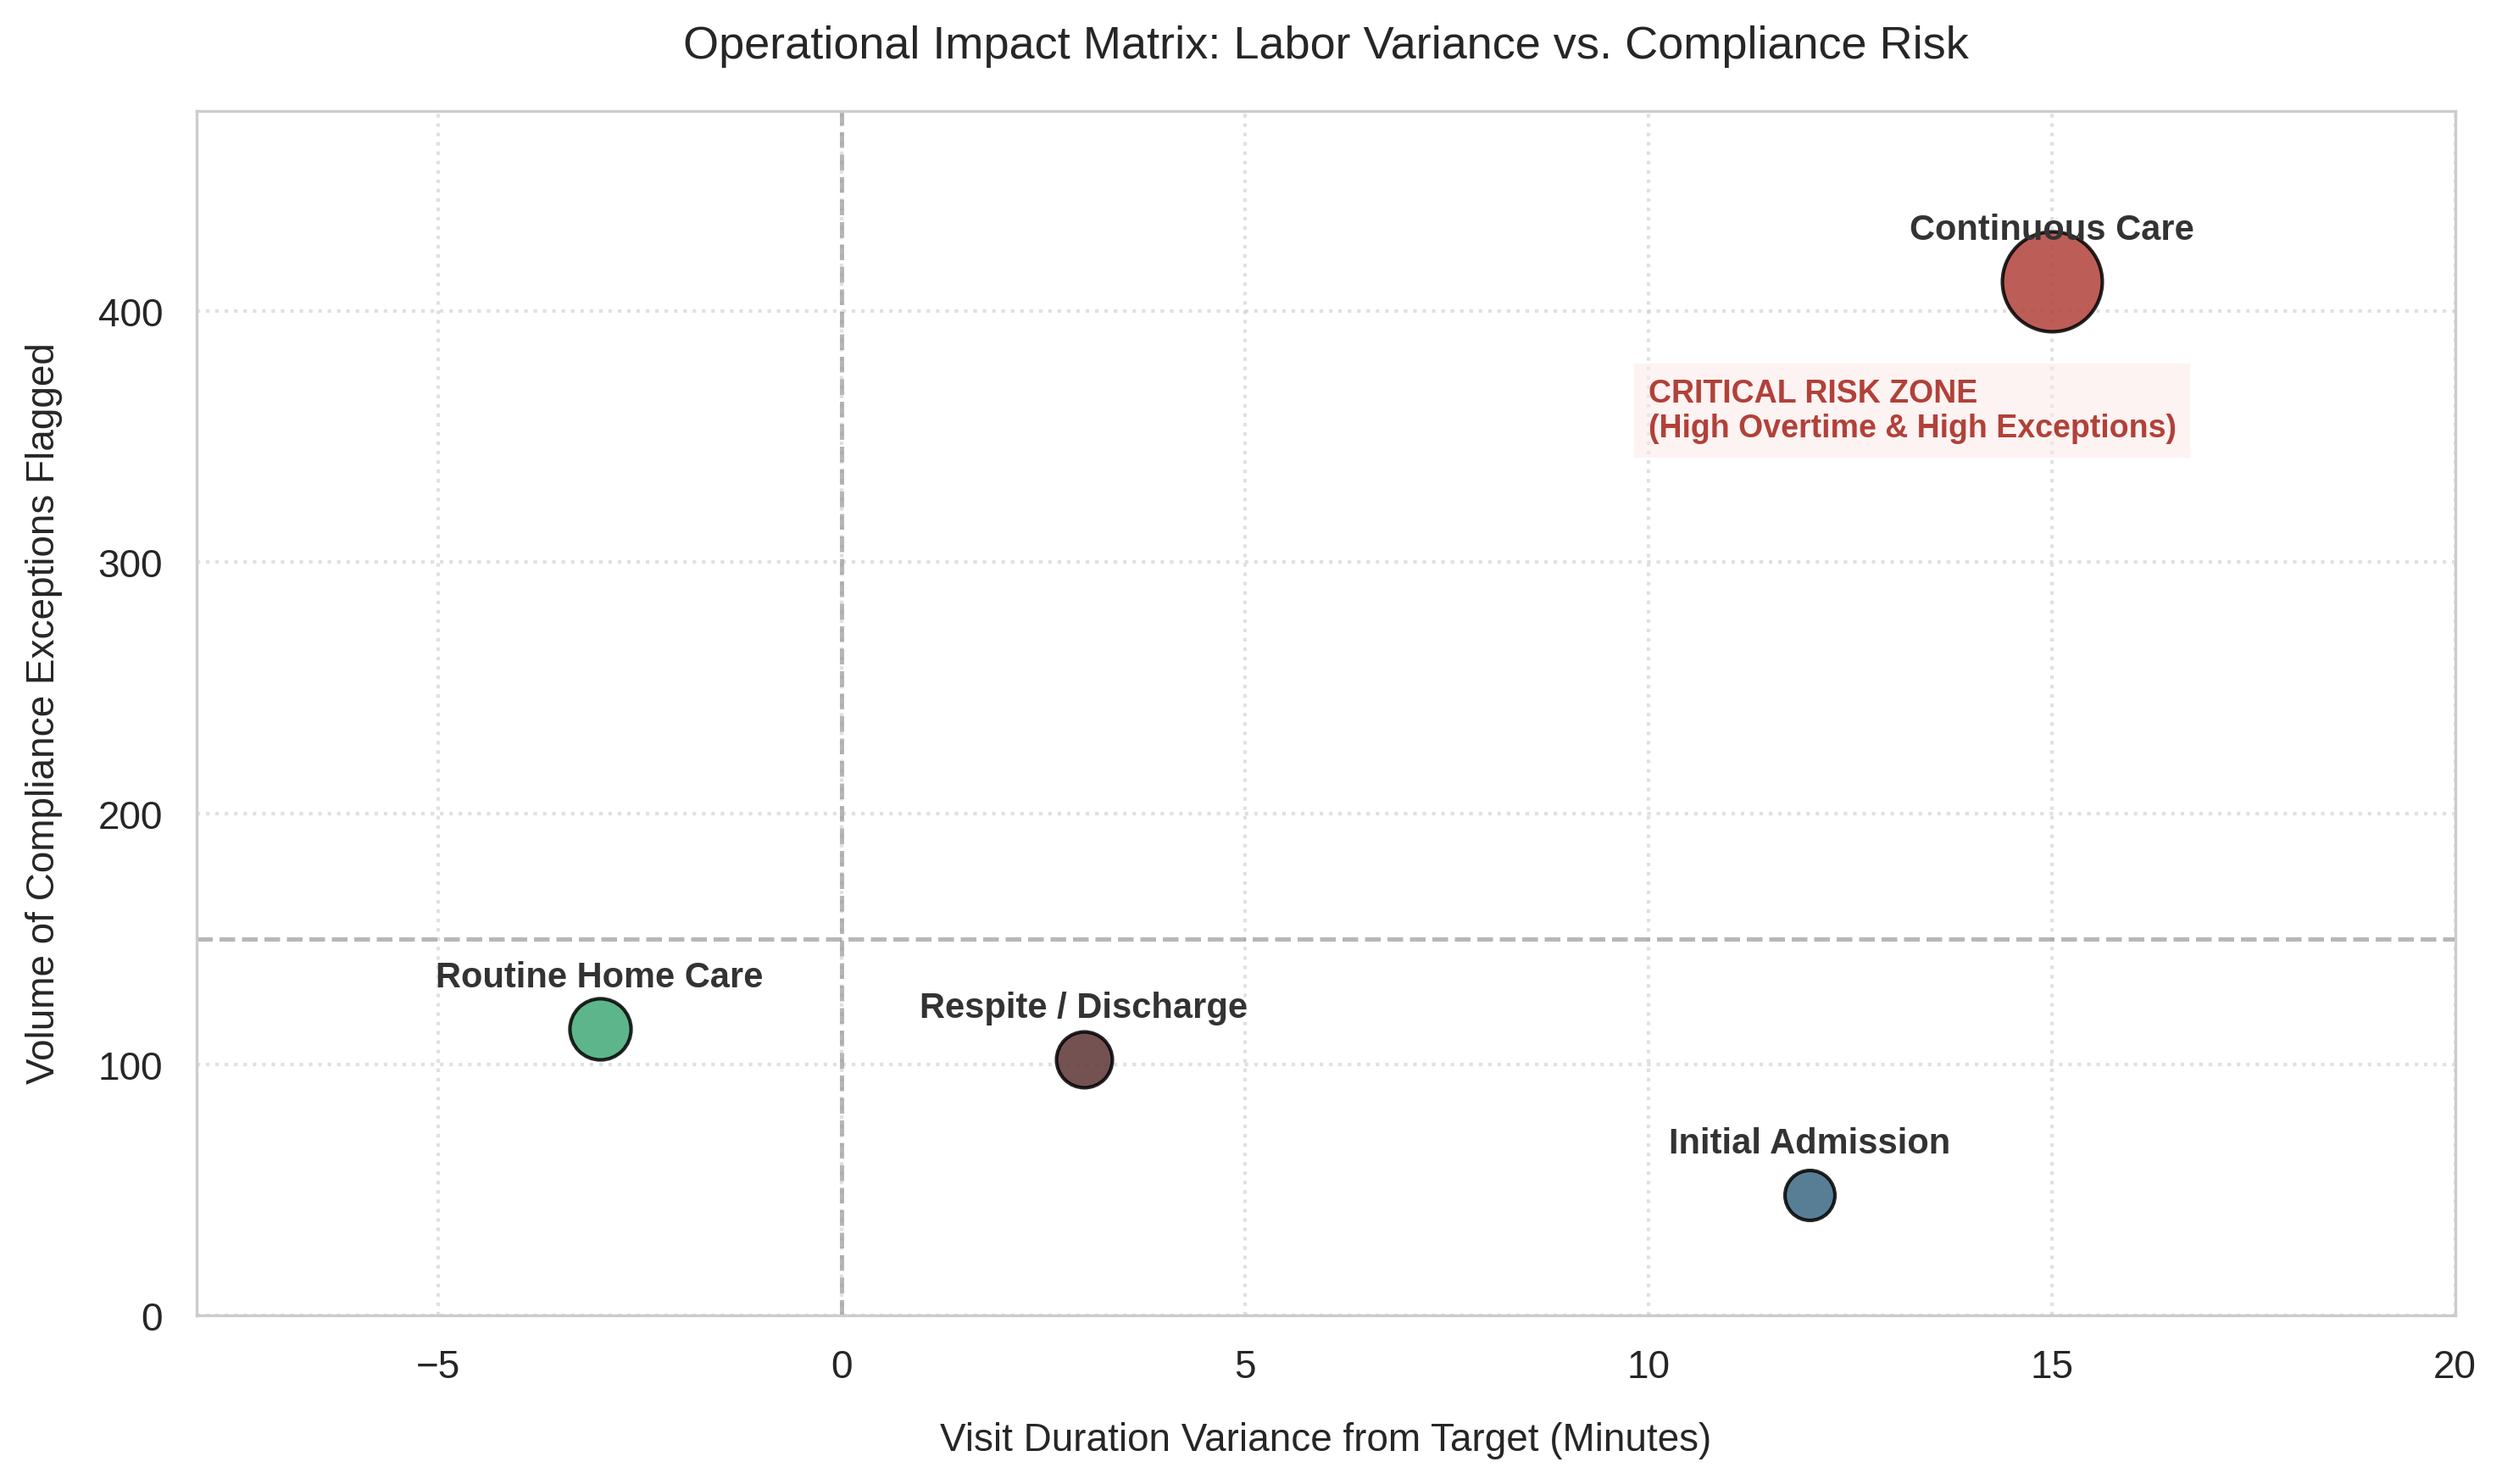

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean, professional plotting parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'axes.edgecolor': '#CCCCCC',
    'axes.linewidth': 0.8
})

# --- DATASET FROM YOUR EXCEL AUDIT ---
categories = ['Initial Admission', 'Routine Home Care', 'Continuous Care', 'Respite / Discharge']
variance_mins = [12, -3, 15, 3]          # From your sheet's Duration Variance column
exceptions_flagged = [48, 114, 412, 102] # From your sheet's Exceptions column

# Custom color palette matching your portfolio theme
colors = ['#3B6784', '#41A877', '#B14139', '#5C3433']
sizes = [200, 300, 800, 250] # Scale bubble size by volume of audited records

# --- CREATE OPERATIONAL RISK MATRIX SCATTER PLOT ---
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot each category as a distinct bubble
for i, cat in enumerate(categories):
    ax.scatter(variance_mins[i], exceptions_flagged[i],
               s=sizes[i], color=colors[i], alpha=0.85,
               edgecolors='black', linewidth=1, label=cat)

# Add quadrant operational thresholds (Averages from your totals row)
ax.axvline(x=0, color='#999999', linestyle='--', linewidth=1.2, alpha=0.7) # Target baseline
ax.axhline(y=150, color='#999999', linestyle='--', linewidth=1.2, alpha=0.7) # High exception threshold

# Labels and Text Annotations
ax.set_title('Operational Impact Matrix: Labor Variance vs. Compliance Risk', fontsize=13, pad=15)
ax.set_xlabel('Visit Duration Variance from Target (Minutes)', fontsize=11, labelpad=10)
ax.set_ylabel('Volume of Compliance Exceptions Flagged', fontsize=11, labelpad=10)

# Annotate the critical outlier quadrant
ax.text(10, 350, 'CRITICAL RISK ZONE\n(High Overtime & High Exceptions)',
        color='#B14139', fontsize=9, fontweight='bold', bbox=dict(facecolor='#FCE8E6', alpha=0.5, edgecolor='none'))

# Add labels directly next to the bubbles for perfect clarity
for i, cat in enumerate(categories):
    ax.annotate(cat, (variance_mins[i], exceptions_flagged[i]),
                textcoords="offset points", xytext=(0,12), ha='center',
                fontsize=10, fontweight='bold', color='#333333')

# Clean up layout margins
ax.set_xlim(-8, 20)
ax.set_ylim(0, 480)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('Operational_Impact_Risk_Matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Create a DataFrame from the data used in the plot
report_data = {
    'Category': categories,
    'Variance (Minutes)': variance_mins,
    'Exceptions Flagged': exceptions_flagged
}

df_report = pd.DataFrame(report_data)

# Save the DataFrame to a CSV file
csv_filename = 'operational_risk_report.csv'
df_report.to_csv(csv_filename, index=False)

print(f"Report saved to {csv_filename}")
display(df_report)

Report saved to operational_risk_report.csv


,Category,Variance (Minutes),Exceptions Flagged
0,Initial Admission,12,48
1,Routine Home Care,-3,114
2,Continuous Care,15,412
3,Respite / Discharge,3,102


## How to import `operational_risk_report.csv` into Google Sheets:

1.  **Download the CSV file:** You should see a download icon next to the `operational_risk_report.csv` file in the Colab file browser (left sidebar).
2.  **Open Google Sheets:** Go to [sheets.google.com](https://docs.google.com/spreadsheets/)
3.  **Create a new spreadsheet** or open an existing one.
4.  Go to `File > Import`.
5.  Select the `Upload` tab.
6.  Click `Select a file from your device` and choose the `operational_risk_report.csv` file you downloaded.
7.  In the import options, you can usually leave the default settings (e.g., "Detect automatically" for separator type).
8.  Click `Import data`.